# 04. Cohort & Repeat-Purchase Stability Analysis

## Objective

Evaluate whether the 90-day repeat-purchase outcome is stable across first-purchase cohorts and examine when repeat purchases occur after the initial order.

The analysis focuses on:

- monthly cohort size
- monthly 90-day repeat-purchase rate
- complete vs partial cohorts
- cumulative 30/60/90-day repeat rates
- time-to-repeat distribution
- near-immediate repeat-order sensitivity

In [1]:
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cohort Summary 불러오기
conn = sqlite3.connect(
    "../data/processed/olist.db"
)

cohort_df = pd.read_sql_query(
    """
    SELECT *
    FROM cohort_90d_summary
    ORDER BY first_purchase_month
    """,
    conn
)

conn.close()

cohort_df

,first_purchase_month,eligible_customer_count,repeat_customer_count,repeat_rate_pct,is_full_month_cohort
0,2016-09,1,0,0.00,0
1,2016-10,317,3,0.95,1
2,2016-12,1,1,100.00,1
3,2017-01,726,25,3.44,1
4,2017-02,1736,26,1.50,1
5,2017-03,2643,57,2.16,1
6,2017-04,2323,47,2.02,1
7,2017-05,3592,99,2.76,1
8,2017-06,3148,90,2.86,1
9,2017-07,3843,95,2.47,1


In [3]:
# Full Cohort만 보기
full_cohort_df = (
    cohort_df[
        cohort_df[
            "is_full_month_cohort"
        ] == 1
    ]
)

full_cohort_df

,first_purchase_month,eligible_customer_count,repeat_customer_count,repeat_rate_pct,is_full_month_cohort
1,2016-10,317,3,0.95,1
2,2016-12,1,1,100.00,1
3,2017-01,726,25,3.44,1
4,2017-02,1736,26,1.50,1
5,2017-03,2643,57,2.16,1
6,2017-04,2323,47,2.02,1
7,2017-05,3592,99,2.76,1
8,2017-06,3148,90,2.86,1
9,2017-07,3843,95,2.47,1
10,2017-08,4204,113,2.69,1


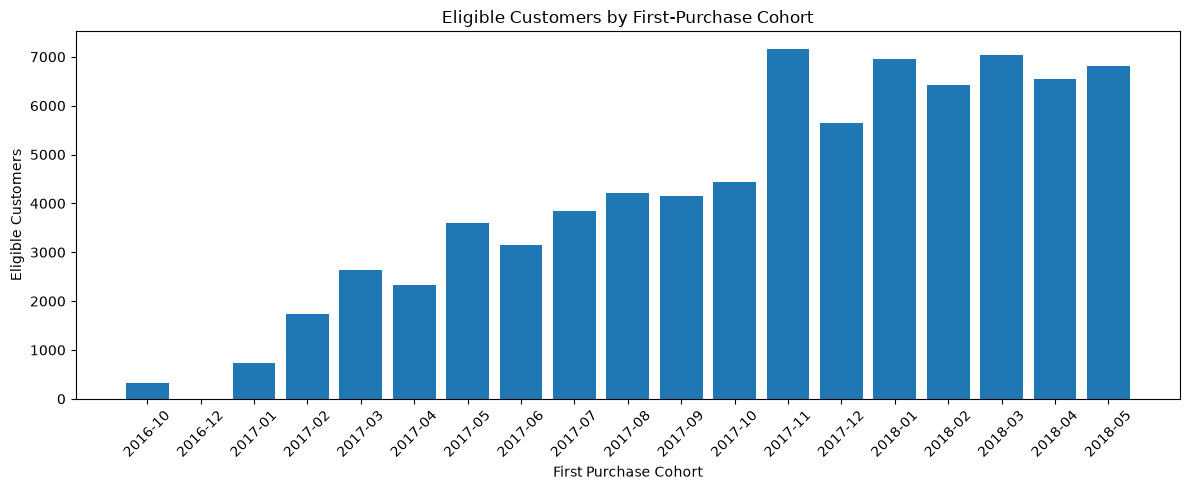

In [4]:
# 월별 Cohort 규모 그래프
plt.figure(
    figsize=(12, 5)
)

plt.bar(
    full_cohort_df[
        "first_purchase_month"
    ],
    full_cohort_df[
        "eligible_customer_count"
    ]
)

plt.xlabel(
    "First Purchase Cohort"
)

plt.ylabel(
    "Eligible Customers"
)

plt.title(
    "Eligible Customers by First-Purchase Cohort"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/cohort_customer_count.png"
)

plt.show()

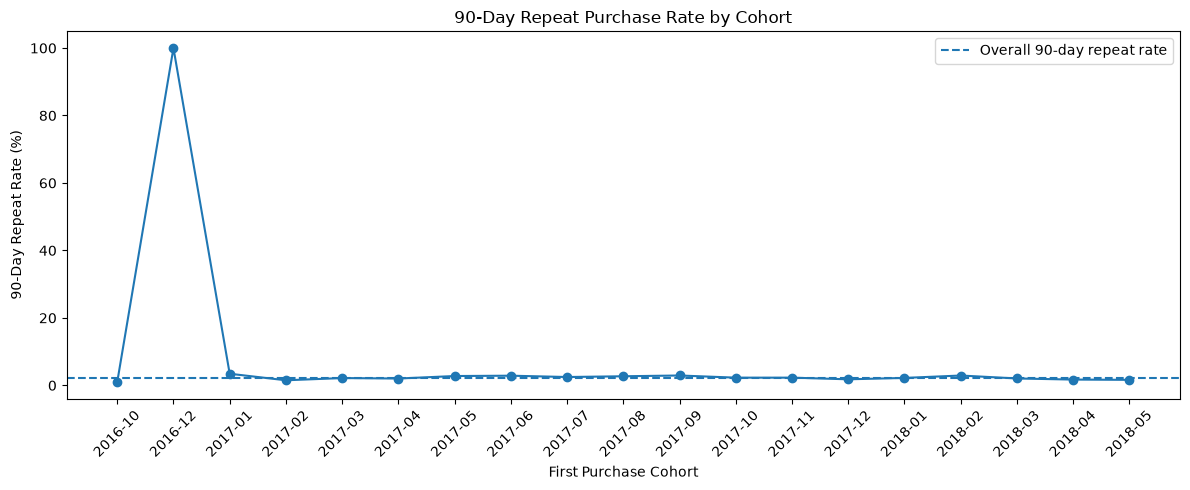

In [5]:
# 월별 90일 재구매율
overall_repeat_rate = (
    1766
    / 78505
    * 100
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    full_cohort_df[
        "first_purchase_month"
    ],
    full_cohort_df[
        "repeat_rate_pct"
    ],
    marker="o"
)

plt.axhline(
    y=overall_repeat_rate,
    linestyle="--",
    label="Overall 90-day repeat rate"
)

plt.xlabel(
    "First Purchase Cohort"
)

plt.ylabel(
    "90-Day Repeat Rate (%)"
)

plt.title(
    "90-Day Repeat Purchase Rate by Cohort"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/cohort_90d_repeat_rate.png"
)

plt.show()

In [6]:
# 30/60/90일 그래프
conn = sqlite3.connect(
    "../data/processed/olist.db"
)

horizon_df = pd.read_sql_query(
    """
    WITH observation_bounds AS (

        SELECT
            max(
                order_approved_at
            ) AS observation_end

        FROM order_base

        WHERE
            is_approved_order = 1
    )


    SELECT
        '30d' AS horizon,

        count(*) AS eligible_customer_count,

        sum(
            CASE
                WHEN c.second_approved_at IS NOT NULL

                AND c.second_approved_at
                    <= datetime(
                        c.first_approved_at,
                        '+30 day'
                    )

                    THEN 1

                ELSE 0
            END
        ) AS repeat_customer_count,

        round(
            100.0
            *
            sum(
                CASE
                    WHEN c.second_approved_at IS NOT NULL

                    AND c.second_approved_at
                        <= datetime(
                            c.first_approved_at,
                            '+30 day'
                        )

                        THEN 1

                    ELSE 0
                END
            )
            / count(*),
            2
        ) AS repeat_rate_pct

    FROM customer_repeat_90d_base AS c

    CROSS JOIN observation_bounds AS b

    WHERE
        c.first_approved_at
            <= datetime(
                b.observation_end,
                '-30 day'
            )


    UNION ALL


    SELECT
        '60d',
        count(*),

        sum(
            CASE
                WHEN c.second_approved_at IS NOT NULL

                AND c.second_approved_at
                    <= datetime(
                        c.first_approved_at,
                        '+60 day'
                    )

                    THEN 1

                ELSE 0
            END
        ),

        round(
            100.0
            *
            sum(
                CASE
                    WHEN c.second_approved_at IS NOT NULL

                    AND c.second_approved_at
                        <= datetime(
                            c.first_approved_at,
                            '+60 day'
                        )

                        THEN 1

                    ELSE 0
                END
            )
            / count(*),
            2
        )

    FROM customer_repeat_90d_base AS c

    CROSS JOIN observation_bounds AS b

    WHERE
        c.first_approved_at
            <= datetime(
                b.observation_end,
                '-60 day'
            )


    UNION ALL


    SELECT
        '90d',
        count(*),

        sum(
            CASE
                WHEN c.repeat_90d = 1
                    THEN 1
                ELSE 0
            END
        ),

        round(
            avg(c.repeat_90d) * 100,
            2
        )

    FROM customer_repeat_90d_base AS c

    WHERE
        c.is_eligible_90d = 1;
    """,
    conn
)

conn.close()

horizon_df

,horizon,eligible_customer_count,repeat_customer_count,repeat_rate_pct
0,30d,90718,1386,1.53
1,60d,84552,1626,1.92
2,90d,78505,1766,2.25


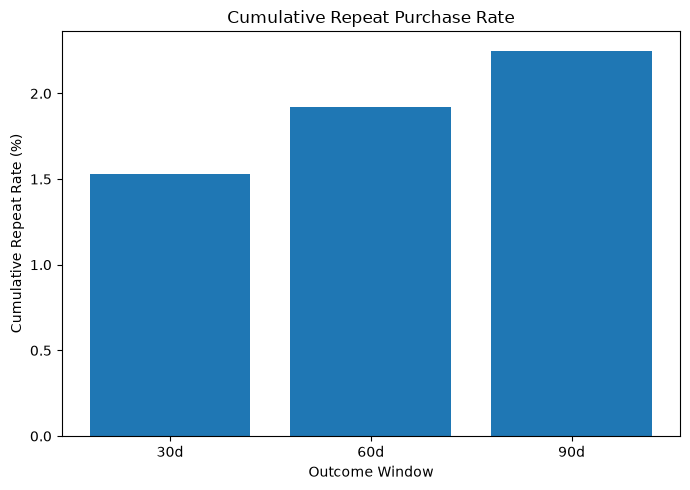

In [7]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    horizon_df["horizon"],
    horizon_df["repeat_rate_pct"]
)

plt.xlabel(
    "Outcome Window"
)

plt.ylabel(
    "Cumulative Repeat Rate (%)"
)

plt.title(
    "Cumulative Repeat Purchase Rate"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/cumulative_repeat_rate.png"
)

plt.show()

In [8]:
# days_to_repeat 분포
conn = sqlite3.connect(
    "../data/processed/olist.db"
)

repeat_interval_df = pd.read_sql_query(
    """
    SELECT
        customer_unique_id,

        julianday(second_approved_at)
        - julianday(first_approved_at)
            AS days_to_repeat

    FROM customer_repeat_90d_base

    WHERE
        repeat_90d = 1
    """,
    conn
)

conn.close()

print(
    repeat_interval_df[
        "days_to_repeat"
    ]
    .describe()
)

count    1766.000000
mean       19.496247
std        25.611322
min         0.000012
25%         0.000093
50%         5.730781
75%        34.524740
max        89.996782
Name: days_to_repeat, dtype: float64


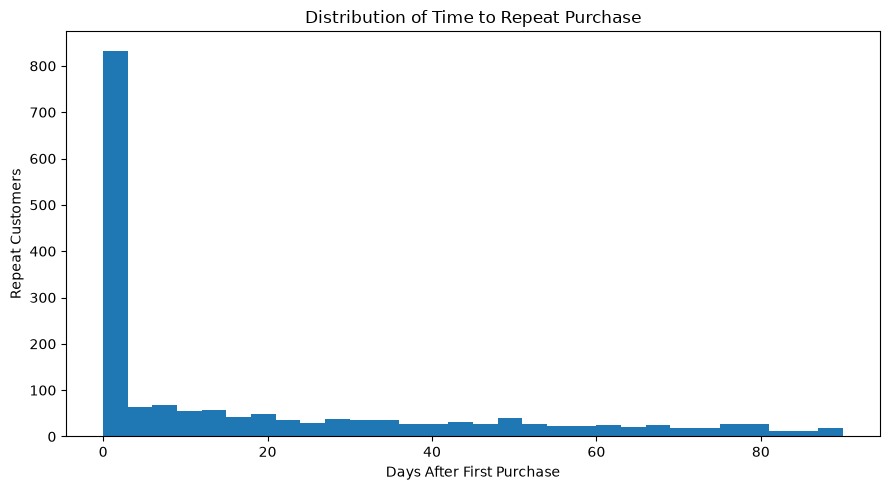

In [9]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    repeat_interval_df[
        "days_to_repeat"
    ],
    bins=30
)

plt.xlabel(
    "Days After First Purchase"
)

plt.ylabel(
    "Repeat Customers"
)

plt.title(
    "Distribution of Time to Repeat Purchase"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/days_to_repeat_distribution.png"
)

plt.show()

In [10]:
# 0~1일 구간
repeat_within_1d_df = (
    repeat_interval_df[
        repeat_interval_df[
            "days_to_repeat"
        ] <= 1
    ]
)

print(
    repeat_within_1d_df[
        "days_to_repeat"
    ]
    .describe()
)

print(
    "within 1 day:",
    len(repeat_within_1d_df)
)

count    773.000000
mean       0.035955
std        0.149116
min        0.000012
25%        0.000023
50%        0.000058
75%        0.003241
max        0.985556
Name: days_to_repeat, dtype: float64
within 1 day: 773
